### ¿Como funciona el negocio de Tik Tok?

**TikTok es una plataforma de monetización de atención que usa algoritmos de precisión para retener usuarios y vender ese tiempo a los anunciantes**. Su negocio cierra el círculo mediante publicidad nativa y comisiones por ventas directas dentro de la app (TikTok Shop). Básicamente, convierten el **entretenimiento viral** en una base de datos masiva para maximizar conversiones de compra.

Los usuarios de TikTok tienen la posibilidad de denunciar vídeos y comentarios que contengan reclamaciones de usuarios. Estos informes identifican el contenido que debe ser revisado por los moderadores. Este proceso genera un gran número de informes de usuarios que son difíciles de abordar rápidamente.

### Objetivo

- El objetivo de este proyecto es construir un modelo de aprendizaje automático que pueda agilizar el proceso de reclamaciones identificando si las afirmaciones hechas en los vídeos son afirmaciones u opiniones. 

### Proyecto  de clasificación de reclamaciones

Recordatorio: En el contexto de la ciencia de datos, **las variables significativas** son aquellas que tienen un impacto directo o indirecto en el resultado de un estudio o proceso. Estas variables pueden ser independientes, dependientes o confusas.

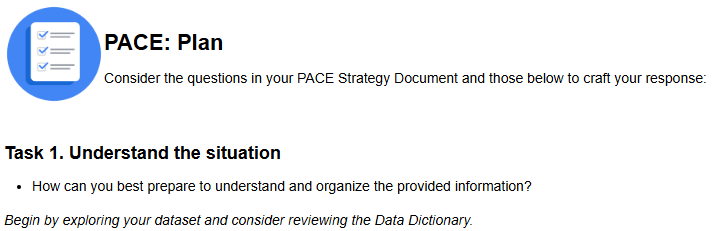

 Begin by exploring your dataset and consider reviewing the Data Dictionary. One can prepare to understand the information by reading the videos data fields and understanding the impact of each one. Reviewing the fact sheet could also provide helpful background information. However, the primary goal is to get the data into Python, inspect it, and provide DeShawn with initial observations. The next step would be to learn more about the data and check for any anomalies.

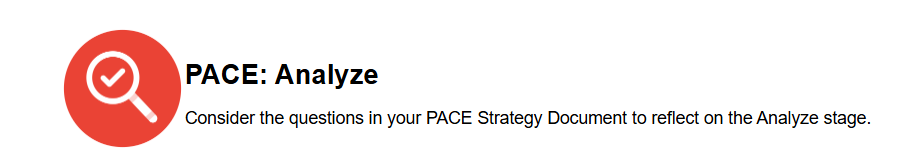

In [1]:
import numpy as np 
import pandas as pd

In [2]:
df_tiktok = pd.read_csv('tiktok_dataset.csv')
df_tiktok

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19377,19378,NaN,7578226840,21,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19378,19379,NaN,6079236179,53,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19379,19380,NaN,2565539685,10,NaN,verified,under review,NaN,NaN,NaN,NaN,NaN
19380,19381,NaN,2969178540,24,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN


## Task 2b. Understand the data - Inspect the data
View and inspect summary information about the dataframe by coding the following:

1. data.head(10)
2. data.info()
3. data.describe()

Consider the following questions:

- Question 1: When reviewing the first few rows of the dataframe, what do you observe about the data? What does each row represent? 
                 - Answer:The data lacks uniformity, indicating a clear need for data cleaning and imputation before analysis.

- Question 2: When reviewing the data.info() output, what do you notice about the different variables? Are there any null values? Are all of the variables numeric? Does anything else stand out?
                 - Answer: some of the data is object, we must change to categoric, some of the are categoric such as author ben status and the others numeric like duration.

- Question 3: When reviewing the data.describe() output, what do you notice about the distributions of each variable? Are there any questionable values? Does it seem that there are outlier values?
                 
                - Answer The interaction variables show a **strong right-skew and high dispersion**, with standard deviations exceeding the mean and maximum values that clearly indicate **outliers** (viral videos). Video duration is the only symmetric distribution, while the minimum values of zero in engagement metrics are **questionable** when compared to the minimum view count. Since the mean is inflated by viral hits, the median provides a more accurate representation of the typical video.

In [3]:
df_tiktok.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [4]:
df_tiktok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [5]:
df_tiktok.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


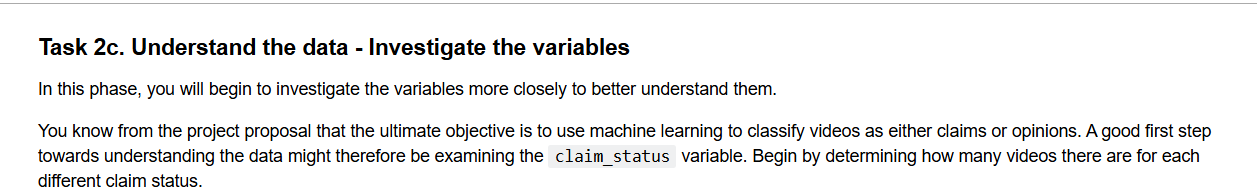

In [6]:
# What are the different values for claim status and how many of each are in the data?
df_tiktok['claim_status'].value_counts()


#Question: What do you notice about the values shown?
#Answer: The most notable observation is that the dataset is highly balanced between the two classes. There are 9,608 claims and 9,476 opinions, representing a nearly 50/50 split


claim_status
claim      9608
opinion    9476
Name: count, dtype: int64

In [51]:
# What is the average view count of videos with "claim" status?
media_claim = df_tiktok[df_tiktok['claim_status'] == 'claim']['video_view_count'].mean()
mediana_claim = df_tiktok[df_tiktok['claim_status'] == 'claim']['video_view_count'].median()
print(f'The average view count for videos with "claim" status is: {media_claim:.2f}')
print(f'The median view count for videos with "claim" status is: {mediana_claim:.2f}')

The average view count for videos with "claim" status is: 501029.45
The median view count for videos with "claim" status is: 501555.00


In [50]:
# What is the average view count of videos with "opinion" status?
media_opinion = df_tiktok[df_tiktok['claim_status'] == 'opinion']['video_view_count'].mean()
mediana_opinion = df_tiktok[df_tiktok['claim_status'] == 'opinion']['video_view_count'].median()
print(f'The average view count for videos with "opinion" status is: {media_opinion:.2f}')
print(f'The median view count for videos with "opinion" status is: {mediana_opinion:.2f}')

The average view count for videos with "opinion" status is: 4956.43
The median view count for videos with "opinion" status is: 4953.00


- Question: What do you notice about the mean and media within each claim category?

There is a stark contrast between the two categories: 'claim' videos have a much higher average view count (501,029) compared to 'opinion' videos (4,956). When comparing these means to the overall median ($9,954$) observed earlier, it is evident that 'claim' videos are driving the high dispersion in the dataset. The fact that the mean for 'claims' is so much higher than the general median suggests that this category is heavily influenced by viral outliers, whereas 'opinion' videos tend to stay well below the average engagement levels.

In [47]:
# Get counts for each group combination of claim status and author ban status
df_tiktok.groupby(['claim_status', 'author_ban_status']).count()[['#']]

#
claim_status author_ban_status      
claim        active             6566
             banned             1439
             under review       1603
opinion      active             8817
             banned              196
             under review        463

In [22]:
#Calculate the median video share count of each author ban status.

median_share_count = df_tiktok.groupby('author_ban_status')['video_share_count'].median().reset_index(name='median_share_count')
median_share_count.index += 1
median_share_count

,author_ban_status,median_share_count
1,active,437.0
2,banned,14468.0
3,under review,9444.0


Use groupby() to group the data by author_ban_status, then use agg() to get the count, mean, and median of each of the following columns:

- video_view_count
- video_like_count
- video_share_count

Remember, the argument for the agg() function is a dictionary whose keys are columns. The values for each column are a list of the calculations you want to perform.

In [33]:
# Agrupando por estatus de baneo del autor y calculando count, mean y median
stats_by_author = df_tiktok.groupby('author_ban_status').agg({
    'video_view_count': ['count', 'mean', 'median'],
    'video_like_count': ['count', 'mean', 'median'],
    'video_share_count': ['count', 'mean', 'median']
})

# Visualizar el resultado
stats_by_author

video_view_count                          video_like_count  \
                             count           mean    median            count   
author_ban_status                                                              
active                       15383  215927.039524    8616.0            15383   
banned                        1635  445845.439144  448201.0             1635   
under review                  2066  392204.836399  365245.5             2066   

                                           video_share_count                \
                            mean    median             count          mean   
author_ban_status                                                            
active              71036.533836    2222.0             15383  14111.466164   
banned             153017.236697  105573.0              1635  29998.942508   
under review       128718.050339   71204.5              2066  25774.696999   

                            
                    median  
author_ban_status           
active               437.0  
banned             14468.0  
under review        9444.0

In [ ]:

df_tiktok['likes_per_view'] = df_tiktok['video_like_count'] / df_tiktok['video_view_count']


df_tiktok['comments_per_view'] = df_tiktok['video_comment_count'] / df_tiktok['video_view_count']

df_tiktok['shares_per_view'] = df_tiktok['video_share_count'] / df_tiktok['video_view_count']

df_tiktok[['likes_per_view', 'comments_per_view', 'shares_per_view']].head(10)

,likes_per_view,comments_per_view,shares_per_view
0,0.056584,0.000000,0.000702
1,0.549096,0.004855,0.135111
2,0.108282,0.000365,0.003168
3,0.548459,0.001335,0.079569
4,0.622910,0.002706,0.073175
5,0.521454,0.005516,0.185069
6,0.647958,0.007258,0.258429
7,0.001958,0.000020,0.000091
8,0.409364,0.001088,0.042306
9,0.183612,0.002727,0.072714


In [46]:
stats_by_author = df_tiktok.groupby(['claim_status', 'author_ban_status']).agg({
    'likes_per_view': ['count', 'mean', 'median'],
    'comments_per_view': ['count', 'mean', 'median'],
    'shares_per_view': ['count', 'mean', 'median']
})
stats_by_author

likes_per_view                      \
                                        count      mean    median   
claim_status author_ban_status                                      
claim        active                      6566  0.329542  0.326538   
             banned                      1439  0.345071  0.358909   
             under review                1603  0.327997  0.320867   
opinion      active                      8817  0.219744  0.218330   
             banned                       196  0.206868  0.198483   
             under review                 463  0.226394  0.228051   

                               comments_per_view                      \
                                           count      mean    median   
claim_status author_ban_status                                         
claim        active                         6566  0.001393  0.000776   
             banned                         1439  0.001377  0.000746   
             under review                   1603  0.001367  0.000789   
opinion      active                         8817  0.000517  0.000252   
             banned                          196  0.000434  0.000193   
             under review                    463  0.000536  0.000293   

                               shares_per_view                      
                                         count      mean    median  
claim_status author_ban_status                                      
claim        active                       6566  0.065456  0.049279  
             banned                       1439  0.067893  0.051606  
             under review                 1603  0.065733  0.049967  
opinion      active                       8817  0.043729  0.032405  
             banned                        196  0.040531  0.030728  
             under review                  463  0.044472  0.035027

1. What percentage of the data is comprised of claims and what percentage is comprised of opinions?
- El dataset está prácticamente balanceado con un 50.35% de "claims" y un 49.65% de "opinions". Este equilibrio asegura que el modelo no tenga sesgos hacia una categoría y pueda aprender de ambas de manera equitativa.

2. What factors correlate with a video's claim status?
- El factor con mayor correlación es el volumen masivo de visualizaciones, ya que los "claims" promedian 504327 ~500k vistas frente a solo 4942.5 ~5k de las opiniones. Esto indica que la viralidad o el contenido polémico están directamente ligados a un estatus de reclamación.

3. What factors correlate with a video's engagement level?
- El engagement correlaciona positivamente con el estatus de baneo del autor, ya que los usuarios "banned" presentan las tasas más altas de likes, comentarios y shares por vista. Esto sugiere que un alto nivel de interacción emocional en la audiencia es un indicador clave para la revisión o sanción de una cuenta.